# Assignment


## Task 3: Transfer Learning

In this task, you will apply transfer learning using a pretrained ResNet50 model (use `ResNet50_Weights.IMAGENET1K_V2`) trained on ImageNet.
https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html

Transfer learning is a powerful machine learning technique for leveraging knowledge learned from one task and applying it to a new task. For instance, if a model has been trained to recognize raccoons, the features it has learned (such as shapes, textures, or patterns) can be useful for identifying tanukis, animals with similar visual characteristics. This approach is particularly valuable when the available dataset for the new task is limited in size, making it difficult to train a full-scale model from scratch. The typical workflow for transfer learning in deep learning involves several key steps:

1. **Starting with a pretrained model:** The architecture of a model trained on a large dataset is (partially) replicated, and the weights of some of its layers are imported.
2. **Freezing the pretrained layers:** These layers are frozen (i.e., excluded from the backpropagation update) to prevent the information learned from the initial task from being overwritten during the new training process.
3. **Adding new trainable layers:** These layers are introduced on top of the frozen ones and are specifically designed to adapt the previous knowledge to the new task.
4. **Training on the new dataset:** The model with the new layers is then trained using data from the current task.
5. **Fine-tuning (optional):** In some cases, the entire model (or parts of it) is unfrozen and retrained with a low learning rate. This fine-tuning allows the model to adapt more precisely to the new dataset, often resulting in improved performance.

You will use pretrained features from models trained on a large-scale image recognition dataset, study the effect of transfer learning on model performance and training time, and compare it to the baseline CNN model you trained from scratch in the previous section. You can find an example
of transfer learning here:
https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

Create a new notebook `transferlearning.ipynb`. Again, copy the dataset logic from the first task.

### 1. Set up the classification

- Choose the same metric(s) for this task as you did in the previous one.

### 2. Set up the base model

- Instantiate the model with the ImageNet pretrained weights. Do not include the final fully connected classification layer. _(Note: this is the last layer of the network.)_
- Freeze all layers in the base model.
- Add one or more fully connected layers on top of the base model to fit the classification task.
- Add one dropout layer before the last layer(s). Optionally, add more.
- Print the final architecture.

### 3. Train your model

- For the initial model, start with the best hyperparameters found while optimizing the baseline (when applicable).
- Train your initial model using the previously selected loss function and evaluate the training and validation losses.
- Evaluate the model using the same performance metric(s) chosen in Task 2.
- Ensure that the model runs without errors and that the loss decreases more or less smoothly.
- Plot the training and validation curves.
- Again, tune your hyperparameters in a systematic way, but you do not need to perform a full-scale analysis.

### 4. Train your model on the full dataset

- Retrain your model using the complete training dataset (including the validation dataset), using your previous set of optimal hyperparameters.
- Plot the training curve.
- Save and reload your model.

### 5. Fine-tuning the entire model

- Unfreeze all or part of the base model and train the whole model end-to-end for the same number of epochs as you trained the pretrained model.
- If you notice a sudden drop in performance on the training dataset, reload the model and try again with a smaller learning rate. If there is no sign of improvement, skip this step and use the saved model from the previous step in the following parts. Save the best model.
- Test the saved model on the test dataset and print the performance metric(s) you chose for this problem.
- Display the confusion matrix.
- Plot a few samples from the test dataset (without preprocessing) with their predictions (after preprocessing).

---

In your report, describe the transfer learning you performed, including the following:

- **Model:** How did you choose the architecture for the final layers you added to the pretrained model?
- **Performance:** How did the pretrained model's training curve compare to the final baseline model?
- **Fine-tuning:** Describe any hyperparameters you changed or further fine-tuning you performed.
- **Transfer Learning:** Discuss, based on this experience, the advantages and disadvantages of this approach.


# Solution


Sources

- https://docs.pytorch.org/vision/main/models.html
- https://docs.pytorch.org/vision/main/models.html#using-the-pre-trained-models (resnet50 trained on images with specific transforms!)


Structure

1. Download and explore
   - describe augmentation (same as for task 2)
2. Custom model 1: ResNet50 + baseline model architecture with same hyperparameters
   - evaluate model performance
   - compare performance to baseline model
3. Custom model 2: same but hyperparameters finetuned
   - finetune hyperparameters
   - evaluate model performance
   - compare to baseline model and to custom model 2
4. Custom model 3: same as previous but ResNet50 weights unfrozen and trained
   - finetune hyperparameters
   - evaluate model performance
   - compare to baseline model, custom model 1 and custom model 2
5. Discussion & Conclusion


# 0. Setup


In [1]:
# for test runs of code using limited computing power. Change to 200 for final run
num_epochs = 100
num_epochs_hp = 100

In [2]:
DATA_DIR = "../../data/1_source/"

Note: Torchvision not in original list of libraries used in the course


In [1]:
import itertools
import sys

sys.path.insert(0, "../0_generalcode")

import os

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from torchvision import datasets, models, transforms

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
)

from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt

from pipeline_helper import (
    MyTransform,
    MyPreprocess,
    MyToTensor,
    g_train_mean,
    g_train_std,
    g_train_no_outliers_mean,
    g_train_no_outliers_std,
)
from img_helper import show_images

from gpu_helper import settest_torch_gpu

Uitbreiden met library time om computationele zwaarte te vergelijken tussen modellen?


In [2]:
# Set the GPU device if present
device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Prediction shape: (5, 1)  — running on device: cuda


In [5]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

torch.backends.cudnn.benchmark = False

NUM_WORKERS = 6  # set to 0 if Jupyter hangs on Windows
BATCH_SIZE = 256  # full training — targets ~6 GB VRAM
HP_BATCH_SIZE = 64  # k-fold HP search — keeps ≥10 batches/fold on ~750 samples
PREFETCH = 4

In [6]:
# import results of best baseline model from task 2

results_baseline = pd.read_csv("../../results/model_comparison.csv")

In [7]:
results_baseline.head()

,timestamp,run_name,variant,architecture,num_params,lr,dropout,auc,recall,f1,accuracy,precision,threshold
0,2026-05-02 15:13,BaselineCNN_16_32_64_128_2048,Variant A (all data),BaselineCNN(\r\n (conv_block): Sequential(\r\...,628321,0.001,0.5,0.9994,0.98,0.9800,0.9863,0.9800,0.5
1,2026-05-02 15:13,BaselineCNN_16_32_64_128_2048,Variant B (no outliers),BaselineCNN(\r\n (conv_block): Sequential(\r\...,628321,0.001,0.5,0.9954,0.98,0.9245,0.9452,0.8750,0.5
2,2026-05-02 17:45,BaselineCNN_16_32_64_128_2048,Variant A (all data),BaselineCNN(\r\n (conv_block): Sequential(\r\...,628321,0.001,0.5,0.9990,0.96,0.9697,0.9795,0.9796,0.5
3,2026-05-02 17:45,BaselineCNN_16_32_64_128_2048,Variant B (no outliers),BaselineCNN(\r\n (conv_block): Sequential(\r\...,628321,0.001,0.5,0.9935,0.96,0.9143,0.9384,0.8727,0.5
4,2026-05-02 21:44,BaselineCNN_16_32_64_128_2048,Variant A (all data),BaselineCNN(\n (conv_block): Sequential(\n ...,628321,0.001,0.3,0.9996,1.00,0.9804,0.9863,0.9615,0.5


In [8]:
images_info = pd.read_csv(DATA_DIR + "/images_info.csv")

### Robustness against task 2


In [ ]:
# load baseline model
baseline_model = torch.load(
    "../2_basemodel/baseline_best.pth", map_location=torch.device(device)
)

In [10]:
# choose relevant row from baseline results
results_baseline = results_baseline.loc[0]

In [11]:
results_baseline["weight_decay"] = 1e-4

In [12]:
# initialize hyperparameters from best baseline model
baseline_config = {
    "lr": results_baseline["lr"].item(),
    "dropout": results_baseline["dropout"].item(),
    # "weight_decay": results_baseline["weight_decay"].item()
    "weight_decay": results_baseline["weight_decay"],
}

best_config = {
    "lr": results_baseline["lr"].item(),
    "dropout": results_baseline["dropout"].item(),
    # "weight_decay": results_baseline["weight_decay"].item()
    "weight_decay": results_baseline["weight_decay"],
}

In [13]:
outliers_removed = False  # True if outliers removed in task 2 (variant B)

In [14]:
def make_filtered_dataset(root, split, transform, info_df, drop_col="drop_sample"):
    """Return an ImageFolder for split, keeping only rows where drop_col == 0."""
    ds = datasets.ImageFolder(os.path.join(root, split), transform=transform)
    keep = set(
        info_df[(info_df["split"] == split) & (info_df[drop_col] == 0)]["filename"]
    )
    valid_idx = [
        i for i, (path, _) in enumerate(ds.samples) if os.path.basename(path) in keep
    ]
    subset = Subset(ds, valid_idx)
    subset.targets = [ds.targets[i] for i in valid_idx]
    return subset

In [15]:
# make datasets without OR with outliers
if outliers_removed:
    train_dataset = make_filtered_dataset(
        DATA_DIR,
        "train",
        MyTransform(
            tr_mean=g_train_no_outliers_mean,
            tr_std=g_train_no_outliers_std,
            channels=3,
            size=(232, 232),
            centercrop=224,
        ),
        images_info,
    )

    val_dataset = datasets.ImageFolder(
        DATA_DIR + "val",
        transform=MyPreprocess(
            tr_mean=g_train_no_outliers_mean,
            tr_std=g_train_no_outliers_std,
            channels=3,
            size=(232, 232),
            centercrop=224,
        ),
    )

    train_dataset_base = make_filtered_dataset(
        DATA_DIR,
        "train",
        transform=MyPreprocess(
            tr_mean=g_train_no_outliers_mean,
            tr_std=g_train_no_outliers_std,
            channels=3,
            size=(232, 232),
            centercrop=224,
        ),
        info_df=images_info,
    )

    test_dataset = datasets.ImageFolder(
        DATA_DIR + "test",
        transform=MyPreprocess(
            tr_mean=g_train_no_outliers_mean,
            tr_std=g_train_no_outliers_std,
            channels=3,
            size=(232, 232),
            centercrop=224,
        ),
    )

    full_train_dataset = ConcatDataset([train_dataset, val_dataset])

else:
    train_dataset = datasets.ImageFolder(
        DATA_DIR + "train",
        transform=MyTransform(
            tr_mean=g_train_mean,
            tr_std=g_train_std,
            channels=3,
            size=(232, 232),
            centercrop=224,
        ),
    )

    val_dataset = datasets.ImageFolder(
        DATA_DIR + "val",
        transform=MyPreprocess(
            tr_mean=g_train_mean,
            tr_std=g_train_std,
            channels=3,
            size=(232, 232),
            centercrop=224,
        ),
    )

    train_dataset_base = datasets.ImageFolder(
        DATA_DIR + "train",
        transform=MyPreprocess(
            tr_mean=g_train_mean,
            tr_std=g_train_std,
            channels=3,
            size=(232, 232),
            centercrop=224,
        ),
    )

    test_dataset = datasets.ImageFolder(
        DATA_DIR + "test",
        transform=MyPreprocess(
            tr_mean=g_train_mean,
            tr_std=g_train_std,
            channels=3,
            size=(232, 232),
            centercrop=224,
        ),
    )

    full_train_dataset = ConcatDataset([train_dataset, val_dataset])

In [16]:
# Build combined datasets for 5-fold cross-validation.
# We load the train directory twice:
#   - with MyTransform() for train folds (augmentation)
#   - with MyPreprocess() for val folds and stratification labels (no augmentation)

combined_aug = ConcatDataset(
    [train_dataset, val_dataset]
)  # augmented train + clean val
combined_base = ConcatDataset(
    [train_dataset_base, val_dataset]
)  # clean train  + clean val

# Labels list for StratifiedKFold (preserves class balance in each fold)
combined_labels = train_dataset_base.targets + val_dataset.targets

print(f"Combined CV dataset size: {len(combined_base)}")
print(
    f"Class distribution — Healthy: {combined_labels.count(0)}, OA: {combined_labels.count(1)}"
)

Combined CV dataset size: 909
Class distribution — Healthy: 596, OA: 313


In [17]:
# calculate pos_weight for hyperparameter search
class_counts = np.bincount([label for _, label in train_dataset])
print(f"Healthy: {class_counts[0]}, OA: {class_counts[1]}")

pos_weight_hp = torch.tensor(
    [class_counts[0] / class_counts[1]], dtype=torch.float32
).to(device)
print(f"pos_weight: {pos_weight_hp.item():.2f}")

Healthy: 500, OA: 250
pos_weight: 2.00


In [18]:
# calculate pos_weight for full training
class_counts = np.bincount([label for _, label in full_train_dataset])
print(f"Healthy: {class_counts[0]}, OA: {class_counts[1]}")

pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(
    device
)
print(f"pos_weight: {pos_weight.item():.4f}")

Healthy: 596, OA: 313
pos_weight: 1.9042


In [19]:
# make dataloaders
_loader_kw = dict(
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=PREFETCH,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, **_loader_kw
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kw)
full_train_loader = DataLoader(
    full_train_dataset, batch_size=BATCH_SIZE, shuffle=True, **_loader_kw
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kw
)

In [20]:
print(f"{["", "No-outlier "][outliers_removed]}Train : {len(train_dataset)} images")
print(f"{["", "No-outlier "][outliers_removed]}Val   : {len(val_dataset)}")
print(f"{["", "No-outlier "][outliers_removed]}Test  : {len(test_dataset)}")

Train : 750 images
Val   : 159
Test  : 146


In [21]:
# Sanity check: one batch shape and pixel range after normalization
imgs, labels = next(iter(train_loader))
print(f"Batch shape   : {imgs.shape}  (B, C, H, W)")
print(f"Pixel range   : [{imgs.min():.3f}, {imgs.max():.3f}]")

Batch shape   : torch.Size([256, 3, 224, 224])  (B, C, H, W)
Pixel range   : [-3.109, 2.019]


---


# 1. Introduction


---


# 2. The pretrained model


## 2.1 Importing the model


In [22]:
resnet = models.resnet50(weights="IMAGENET1K_V2")

## 2.2 Exploring the Resnet50 architecture


#### Inspect architecture, shape of layers


In [23]:
keys = list(resnet.state_dict().keys())

print(
    "First layer: ",
    keys[0],
    " has size ",
    resnet.state_dict()[keys[0]].size(),
    "\nLast layer:  ",
    keys[
        -1
    ],  # refers to `fc.bias`, but same conclusion from `fc.weight` (i.e. `keys[-2]`)
    " has size ",
    resnet.state_dict()[keys[-1]].size(),
)

First layer:  conv1.weight  has size  torch.Size([64, 3, 7, 7]) 
Last layer:   fc.bias  has size  torch.Size([1000])


In [24]:
# print(resnet)

#### The input layer


In [25]:
models.ResNet50_Weights.IMAGENET1K_V2.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

---


# 3. Setup for training and evaluation


### Model training


Hyperparameter search


In [26]:
def train_model(
    model,
    train_loader,
    val_loader,
    criteria,
    optimizer,
    num_epochs,
    device,
    scheduler=None,
):
    """Train the model and track loss, accuracy, recall, and F1 per epoch."""
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_recall": [],
        "val_recall": [],
        "train_f1": [],
        "val_f1": [],
        "grad_norm": [],
    }

    for epoch in range(num_epochs):
        # --- Training phase ---
        model.train()
        running_loss = 0.0
        all_preds, all_labels = [], []
        batch_grad_norms = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(images).squeeze(1)
            loss = criteria(outputs, labels)
            loss.backward()

            # Compute total gradient norm across all parameters
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.detach().norm(2).item() ** 2
            batch_grad_norms.append(total_norm**0.5)

            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).int()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        train_recall = recall_score(all_labels, all_preds, zero_division=0)
        train_f1 = f1_score(all_labels, all_preds, zero_division=0)
        epoch_grad_norm = np.mean(batch_grad_norms)

        # --- Validation phase ---
        model.eval()
        running_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().to(device)
                outputs = model(images).squeeze(1)
                loss = criteria(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).int()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_loss / len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        val_recall = recall_score(all_labels, all_preds, zero_division=0)
        val_f1 = f1_score(all_labels, all_preds, zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_recall"].append(train_recall)
        history["val_recall"].append(val_recall)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        history["grad_norm"].append(epoch_grad_norm)

        if scheduler is not None:
            scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f} | "
                f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}"
                f"Grad Norm: {epoch_grad_norm:.4f}"
            )

    return history

In [27]:
def plot_kfold_curves(fold_metrics, title="K-Fold Validation Curves", show_std=True):
    """Plot per-epoch val_loss, val_acc, val_f1 across folds.
    Thin semi-transparent lines per fold; thick mean line; optional ±std shaded band.
    """
    metrics = ["val_loss", "val_acc", "val_f1"]
    labels = ["Val Loss", "Val Accuracy", "Val F1"]
    colors = ["steelblue", "orange", "green"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title)

    for ax, key, label, color in zip(axes, metrics, labels, colors):
        arrays = np.array(
            [m["history"][key] for m in fold_metrics]
        )  # (n_folds, n_epochs)
        epochs = np.arange(1, arrays.shape[1] + 1)
        mean = arrays.mean(axis=0)
        std = arrays.std(axis=0)

        for i, fold_arr in enumerate(arrays):
            ax.plot(
                epochs,
                fold_arr,
                color=color,
                alpha=0.25,
                linewidth=1,
                label=f"Fold {i+1}" if i == 0 else "_",
            )

        ax.plot(epochs, mean, color=color, linewidth=2.5, label="Mean")

        if show_std:
            ax.fill_between(
                epochs, mean - std, mean + std, color=color, alpha=0.15, label="±1 std"
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(label)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

Plot training history


In [28]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Validation")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy Curves")
    axes[1].legend()

    axes[2].plot(history["train_recall"], label="Train")
    axes[2].plot(history["val_recall"], label="Validation")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Recall")
    axes[2].set_title("Recall Curves")
    axes[2].legend()

    axes[3].plot(history["train_f1"], label="Train")
    axes[3].plot(history["val_f1"], label="Validation")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("F1 Score")
    axes[3].set_title("F1 Score Curves")
    axes[3].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### Model evaluation & selection


In [29]:
def select_threshold_by_recall(fpr, tpr, thresholds, min_recall=0.95):
    """
    Select the classification threshold that achieves at least `min_recall`
    (sensitivity) while keeping the false positive rate as low as possible.

    In a medical screening context we want to a high recall,
    accepting some false positives as a trade-off.
    """
    candidates = np.where(tpr >= min_recall)[0]
    if len(candidates) > 0:
        best_idx = candidates[np.argmin(fpr[candidates])]
    else:
        best_idx = np.argmax(tpr)
    return thresholds[best_idx], best_idx

In [30]:
def evaluate_model(model, test_loader, device, variant_name="", min_recall=0.95):
    """Run inference on test set and return probabilities, labels, and evaluation results."""
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images).squeeze(1)
            probs = torch.sigmoid(outputs)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # ROC and AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve — {variant_name}")
    plt.legend()
    plt.show()

    # Predictions at threshold ~ desired recall
    selected_threshold, new_idx = select_threshold_by_recall(
        fpr=fpr,
        tpr=tpr,
        thresholds=thresholds,
        min_recall=min_recall,
    )

    final_preds = (all_probs >= selected_threshold).astype(int)

    cm = confusion_matrix(all_labels, final_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {variant_name} (threshold=0.50)")
    plt.show()

    acc = accuracy_score(all_labels, final_preds)
    f1 = f1_score(all_labels, final_preds)
    rec = recall_score(all_labels, final_preds)
    prec = precision_score(all_labels, final_preds, zero_division=0)

    print(f"\nTest Metrics ({variant_name}) at threshold={selected_threshold}:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  Precision: {prec:.4f}")

    return {
        "all_probs": all_probs,
        "all_labels": all_labels,
        "final_preds": final_preds,
        "threshold": selected_threshold,
        "auc": roc_auc,
        "accuracy": acc,
        "f1": f1,
        "recall": rec,
        "precision": prec,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
    }

---


# 4. Customized models: training and evaluation


For each customized variant, we simply copy the pretrained model object (`resnet`) and adapt as needed.


## 4.1 Custom model 1


pretrained weights + extra layers similar to baseline model from task 2


### Data preparation


In this variant, we copy the hyperparameters from the baseline model from task 2 and therefore, there is no need to perform a hyperparameter search. The training data and the validation data can immediately be pooled into the final full training dataset.


### Model preparation


In [31]:
custom1 = resnet.to(device)

In this section, our goal is to use the pretrained weights of `ResNet50` for our classification task. These weights should be frozen to make sure that they are not updated during the training of the _extra_ layers that we add on top of the pretrained model.


In [32]:
for param in custom1.parameters():
    param.requires_grad = False

In [33]:
# Check how many parameters are frozen and not frozen
frozen = sum(p.numel() for p in custom1.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in custom1.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Trainable: 0 | Frozen: 25,557,032


Parameters of any layers that are added after this stage are, by default, trainable.


### Training


We replace the final layer of the pretrained model with our own custom block of layers.

The dropout rate and learning rate are taken from our best performing baseline model from task 2. (`best_config`)


In [34]:
custom1.fc = nn.Sequential(
    nn.Linear(2048, 128),
    nn.ReLU(),
    nn.Dropout(best_config["dropout"]),
    nn.Linear(128, 1),
).to(device)

We double-check that the parameters associated with the new layers are indeed trainable.


In [35]:
frozen = sum(p.numel() for p in custom1.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in custom1.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Trainable: 262,401 | Frozen: 23,508,032


In [36]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(
    custom1.parameters(), lr=best_config["lr"], weight_decay=best_config["weight_decay"]
)

warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=num_epochs - 5, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

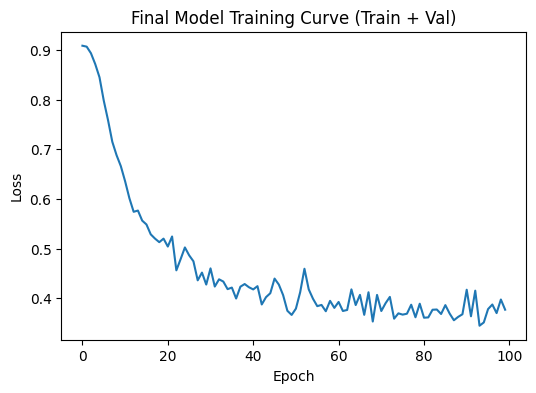

In [37]:
# Full training

custom1.train()
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in full_train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = custom1(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader.dataset)
    train_losses.append(epoch_loss)

    scheduler.step()

# Plot final training curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Training Curve (Train + Val)")
plt.show()

### Evaluation


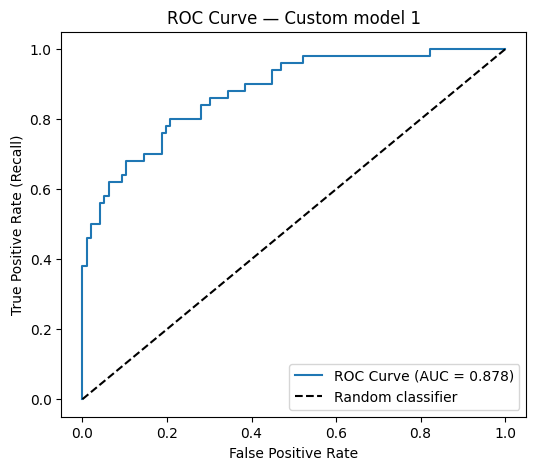

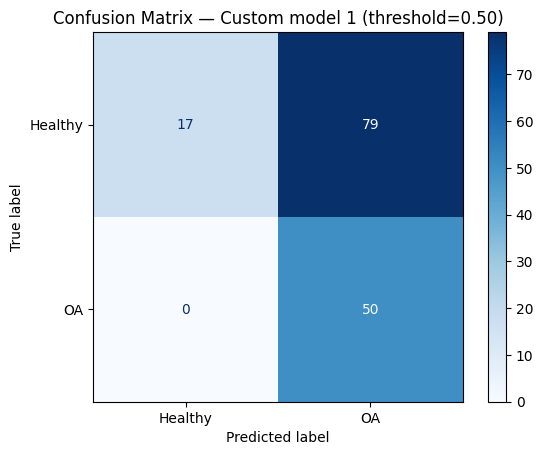


Test Metrics (Custom model 1) at threshold=0.022510122507810593:
  Accuracy : 0.4589
  F1 Score : 0.5587
  Recall   : 1.0000
  Precision: 0.3876


In [38]:
results_custom1 = evaluate_model(
    custom1, test_loader, device, variant_name="Custom model 1", min_recall=1
)

In [39]:
print(f"{'Metric':<20} {'Baseline':>12} {'Custom 1':>12}")
print("-" * 46)
print(
    f"{'Recall':<20} {results_baseline['recall']:>12.4f} {results_custom1['recall']:>12.4f}"
)
print(
    f"{'Precision':<20} {results_baseline['precision']:>12.4f} {results_custom1['precision']:>12.4f}"
)
print(f"{'AUC':<20} {results_baseline['auc']:>12.4f} {results_custom1['auc']:>12.4f}")
print(
    f"{'F1 Score':<20} {results_baseline['f1']:>12.4f} {results_custom1['f1']:>12.4f}"
)
print(
    f"{'Accuracy':<20} {results_baseline['accuracy']:>12.4f} {results_custom1['accuracy']:>12.4f}"
)
print(
    f"{'Threshold':<20} {results_baseline['threshold']:>12.3f} {results_custom1['threshold']:>12.3f}"
)

Metric                   Baseline     Custom 1
----------------------------------------------
Recall                     0.9800       1.0000
Precision                  0.9800       0.3876
AUC                        0.9994       0.8779
F1 Score                   0.9800       0.5587
Accuracy                   0.9863       0.4589
Threshold                   0.500        0.023


### Threshold analysis (if necessary)


Core goal is high recall. If recall contradicts other metrics (specifically precision), decrease threshold of model with lower recall until higher recall is reached, then reassess metrics.


In [40]:
# to_compare = [
#     [results_baseline, results_custom1],
#     ["baseline_model", "custom1"],
#     {"baseline_model": baseline_model, "custom1": custom1},
# ]

# idx_best_recall = np.argmax([to_compare[0][0]["recall"], to_compare[0][1]["recall"]])
# idx_best_precision = np.argmax(
#     [to_compare[0][0]["precision"], to_compare[0][1]["precision"]]
# )

# # if one model is better at both recall and precision, no threshold analysis required (ta_required)
# ta_required = False if (idx_best_recall == idx_best_precision) else True


# if ta_required:
#     # find threshold for worst model that equalizes recall with best model
#     results_worst_recall = to_compare[0][not idx_best_recall]

#     results_best_recall = to_compare[0][idx_best_recall]

#     best_recall = results_best_recall["recall"]

#     new_threshold, new_idx = select_threshold_by_recall(
#         fpr=results_worst_recall["fpr"],
#         tpr=results_worst_recall["tpr"],
#         thresholds=results_worst_recall["thresholds"],
#         min_recall=best_recall,
#     )

#     # recalculate metrics
#     new_preds = (results_worst_recall["all_probs"] > new_threshold).astype(int)
#     new_acc = accuracy_score(results_worst_recall["all_labels"], new_preds)
#     new_f1 = f1_score(results_worst_recall["all_labels"], new_preds)
#     new_rec = recall_score(results_worst_recall["all_labels"], new_preds)
#     new_prec = precision_score(
#         results_worst_recall["all_labels"], new_preds, zero_division=0
#     )

#     print(f"\nRecall-equalized Metrics at threshold={new_threshold}:")
#     print(f"  Accuracy : {new_acc:.4f}")
#     print(f"  F1 Score : {new_f1:.4f}")
#     print(f"  Recall   : {new_rec:.4f}")
#     print(f"  Precision: {new_prec:.4f}")

### Best model

Given identical minimum desired recall, which model achieves the highest precision?


In [41]:
to_compare = [
    [results_baseline, results_custom1],
    ["baseline_model", "custom1"],
    {"baseline_model": baseline_model, "custom1": custom1},
]

best_model_idx = np.argmax(
    [to_compare[0][0]["precision"], to_compare[0][1]["precision"]]
)
best_model_name = to_compare[1][best_model_idx]
best_model = to_compare[2][best_model_name]

print(f"The best model is {best_model_name}.")

The best model is baseline_model.


In [42]:
# if ta_required:
#     # select best model based on recall-equalized precision
#     if new_prec <= results_best_recall["precision"]:
#         best_model = to_compare[2][to_compare[1][idx_best_recall]]
#     else:
#         best_model = to_compare[2][to_compare[1][not idx_best_recall]]

# else:
#     best_model = to_compare[2][to_compare[1][idx_best_recall]]

# print(f"The best model so far is `{to_compare[1]}`.")

### Show images with predictions


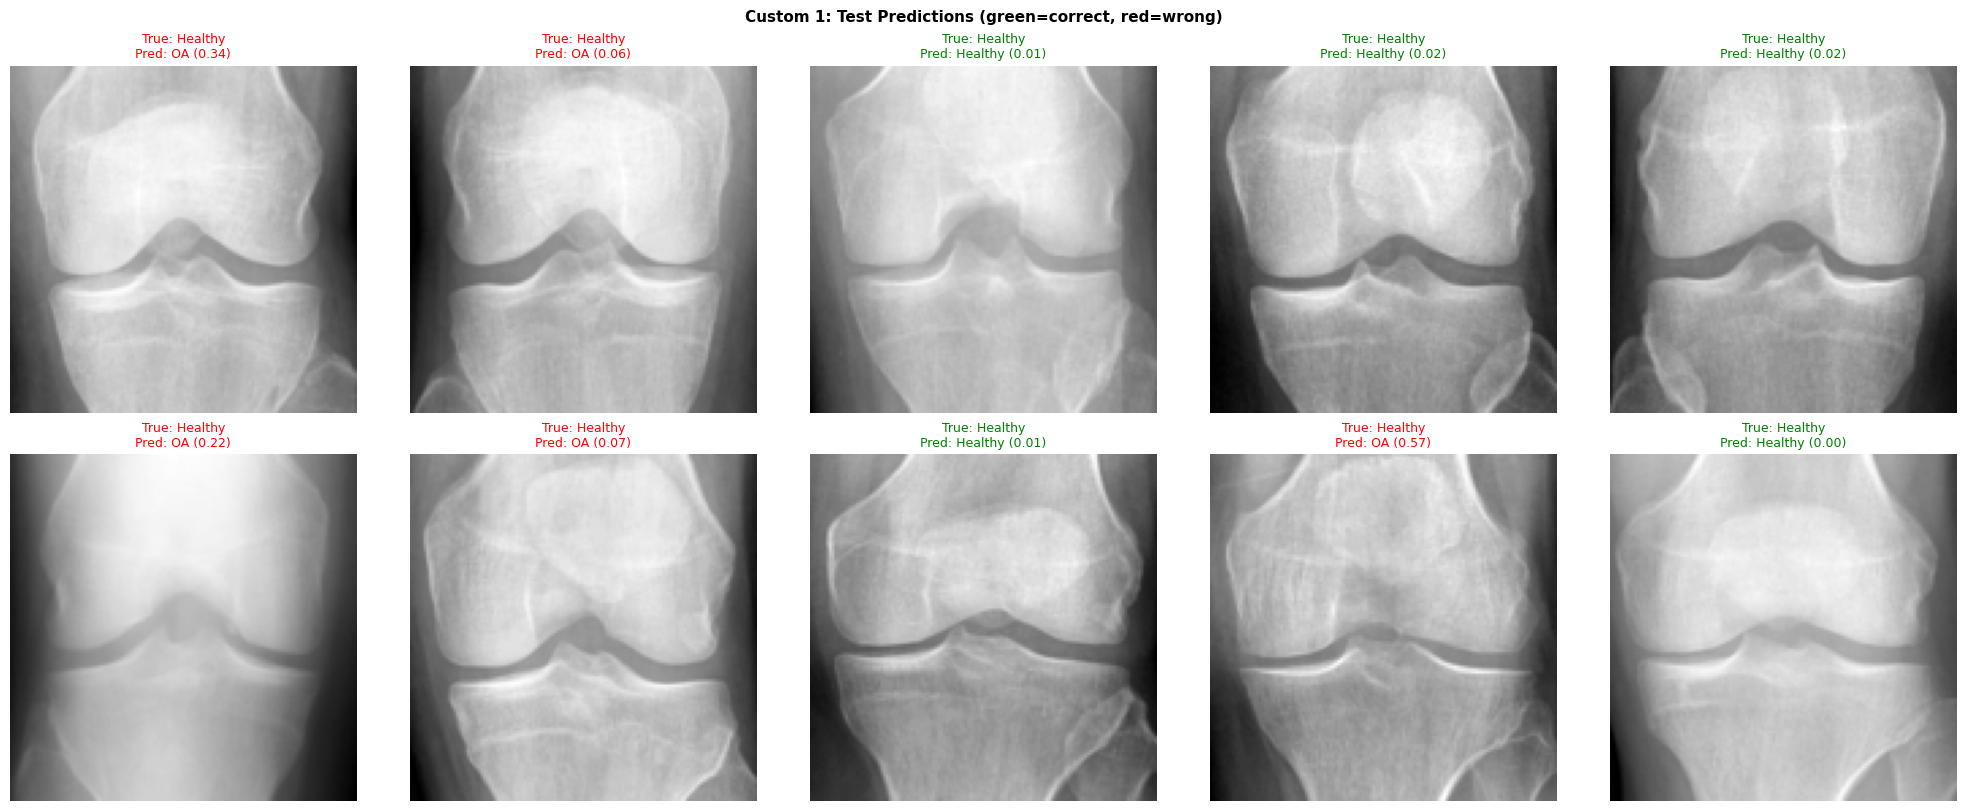

In [43]:
display_dataset = datasets.ImageFolder(DATA_DIR + "test", transform=MyToTensor())
CLASS_NAMES = ["Healthy", "OA"]

show_images(
    list(range(10)),
    display_dataset,
    results_custom1["all_labels"],
    results_custom1["final_preds"],
    results_custom1["all_probs"],
    CLASS_NAMES,
    title="Custom 1: Test Predictions (green=correct, red=wrong)",
)

---


## 4.2 Custom model 2


Identical to `custom1` but with hyperparameters finetuned through a simple hyperparameter search


### Model preparation


In [44]:
custom2 = resnet.to(device)

In [45]:
for param in custom2.parameters():
    param.requires_grad = False

In [46]:
# Check how many parameters are frozen and not frozen
frozen = sum(p.numel() for p in custom2.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in custom2.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Trainable: 0 | Frozen: 23,770,433


### Hyperparameter search


In [ ]:
hp_grid = {
    "lr": [1e-3, 5e-4],
    "dropout": [0.3, 0.5],
    "weight_decay": [1e-4, 1e-2],
}

hp_configs = [
    dict(zip(hp_grid.keys(), combo)) for combo in itertools.product(*hp_grid.values())
]

hp_results = []

N_FOLDS = 5
folds = list(range(1, N_FOLDS + 1))
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for config in hp_configs:
    print(
        f"\n--- HP: lr={config['lr']:.0e}, dropout={config['dropout']}, "
        f"weight_decay={config['weight_decay']:.0e} ---"
    )
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(range(len(combined_base)), combined_labels)
    ):
        print(f"  Fold {fold + 1}/{N_FOLDS}...", end=" ", flush=True)

        fold_train_loader = DataLoader(
            Subset(combined_aug, train_idx),
            batch_size=HP_BATCH_SIZE,
            shuffle=True,
            **_loader_kw,
        )
        fold_val_loader = DataLoader(
            Subset(combined_base, val_idx),
            batch_size=HP_BATCH_SIZE,
            shuffle=False,
            **_loader_kw,
        )

        custom2.fc = nn.Sequential(
            nn.Linear(2048, 128),
            nn.ReLU(),
            nn.Dropout(config["dropout"]),
            nn.Linear(128, 1),
        )

        model = custom2.to(device)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = optim.AdamW(
            model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"]
        )
        warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
        cosine = CosineAnnealingLR(optimizer, T_max=num_epochs_hp - 5, eta_min=1e-6)
        scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

        history = train_model(
            model,
            fold_train_loader,
            fold_val_loader,
            criterion,
            optimizer,
            num_epochs=num_epochs_hp,
            device=device,
            scheduler=scheduler,
        )

        fold_metrics.append(
            {
                "val_loss": history["val_loss"][-1],
                "recall": history["val_recall"][-1],
                "f1": history["val_f1"][-1],
                "history": history,
            }
        )
        print(
            f"val_loss={fold_metrics[-1]['val_loss']:.4f}, recall={fold_metrics[-1]['recall']:.3f}"
        )

    hp_results.append(
        {
            **config,
            "mean_val_loss": np.mean([m["val_loss"] for m in fold_metrics]),
            "std_val_loss": np.std([m["val_loss"] for m in fold_metrics]),
            "mean_recall": np.mean([m["recall"] for m in fold_metrics]),
            "mean_f1": np.mean([m["f1"] for m in fold_metrics]),
            "fold_metrics": fold_metrics,
        }
    )
    print(
        f"  => mean val_loss={hp_results[-1]['mean_val_loss']:.4f} ± "
        f"{hp_results[-1]['std_val_loss']:.4f}"
    )

# Select best HPs: lowest mean 5-fold validation loss
_hp_keys = ["lr", "dropout", "weight_decay"]
best_hp_result = min(hp_results, key=lambda r: r["mean_val_loss"])
best_config = {k: best_hp_result[k] for k in _hp_keys}


print(f"\nBest hyperparameters: {best_config}")
print(
    f"  mean val_loss = {best_hp_result['mean_val_loss']:.4f} ± "
    f"{best_hp_result['std_val_loss']:.4f}"
)
print(f"\nFull best config: {best_config}")

#     print(f"\nTesting: lr={config['lr']}, dropout={config['dropout']}")

# custom2.fc = nn.Sequential(
#     nn.Linear(2048, 128),
#     nn.ReLU(),
#     nn.Dropout(config["dropout"]),
#     nn.Linear(128, 1),
# ).to(device)

#     model = custom2.to(device)
#     criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_hp)
#     optimizer = optim.Adam(model.parameters(), lr=config["lr"])

#     warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
#     cosine = CosineAnnealingLR(optimizer, T_max=epochs - 5, eta_min=1e-6)
#     scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

#     history = train_model(
#         model,
#         train_loader,
#         val_loader,
#         criterion,
#         optimizer,
#         num_epochs=epochs,
#         device=device,
#         scheduler=scheduler,
#     )

#     final_val_loss = min(history["val_loss"])
#     results.append({**config, "val_loss": final_val_loss})

#     if final_val_loss < best_val_loss:
#         best_val_loss = final_val_loss
#         best_config = config
#         best_history = history

# print(f"\nBest config: {best_config} with Val Loss: {best_val_loss:.4f}")

# # Show all results
# for r in results:
#     print(f"  lr={r['lr']}, dropout={r['dropout']} → Val loss: {r['val_loss']:.4f}")


--- HP: lr=1e-03, dropout=0.3, weight_decay=1e-04 ---
  Fold 1/5... Epoch 5/100 | Train Loss: 0.7646, Acc: 0.7345, Recall: 0.7052, F1: 0.6472 | Val Loss: 0.7165, Acc: 0.7912, Recall: 0.7097, F1: 0.6984Grad Norm: 0.6790
Epoch 10/100 | Train Loss: 0.5596, Acc: 0.8363, Recall: 0.7968, F1: 0.7707 | Val Loss: 0.5492, Acc: 0.8352, Recall: 0.7419, F1: 0.7541Grad Norm: 1.1324
Epoch 15/100 | Train Loss: 0.4565, Acc: 0.8501, Recall: 0.8526, F1: 0.7970 | Val Loss: 0.5135, Acc: 0.8462, Recall: 0.7742, F1: 0.7742Grad Norm: 1.0187
Epoch 20/100 | Train Loss: 0.4233, Acc: 0.8721, Recall: 0.8685, F1: 0.8242 | Val Loss: 0.4763, Acc: 0.8571, Recall: 0.8065, F1: 0.7937Grad Norm: 0.9900
Epoch 25/100 | Train Loss: 0.4127, Acc: 0.8900, Recall: 0.8765, F1: 0.8462 | Val Loss: 0.4658, Acc: 0.8736, Recall: 0.8710, F1: 0.8244Grad Norm: 0.8198
Epoch 30/100 | Train Loss: 0.4437, Acc: 0.8624, Recall: 0.8406, F1: 0.8084 | Val Loss: 0.4697, Acc: 0.8516, Recall: 0.9032, F1: 0.8058Grad Norm: 0.8914
Epoch 35/100 | Train

In [ ]:
# Hyperparameter search results — sorted by mean val_loss ascending
_hp_keys = ["lr", "dropout", "weight_decay"]
df_hp_cv = (
    pd.DataFrame(
        [
            {
                **{k: r[k] for k in _hp_keys},
                "mean_val_loss": r["mean_val_loss"],
                "std_val_loss": r["std_val_loss"],
                "mean_recall": r["mean_recall"],
                "mean_f1": r["mean_f1"],
                "best": all(r[k] == best_config[k] for k in _hp_keys),
            }
            for r in hp_results
        ]
    )
    .sort_values("mean_val_loss", ascending=True)
    .reset_index(drop=True)
)
df_hp_cv.index += 1


def _highlight_best(row):
    return [
        "font-weight: bold; background-color: #d4edda" if row["best"] else ""
        for _ in row
    ]


display(
    df_hp_cv.style.apply(_highlight_best, axis=1)
    .format(
        {
            "lr": "{:.0e}",
            "weight_decay": "{:.0e}",
            "mean_val_loss": "{:.4f}",
            "std_val_loss": "±{:.4f}",
            "mean_recall": "{:.3f}",
            "mean_f1": "{:.3f}",
        }
    )
    .set_caption(
        "Hyperparameter Search — 5-Fold CV val_loss (lower is better, ★ = selected)"
    )
)

print(
    f"\nSelected: lr={best_config['lr']:.0e}, dropout={best_config['dropout']}, "
    f"weight_decay={best_config['weight_decay']:.0e}  "
    f"(mean val_loss={best_hp_result['mean_val_loss']:.4f} ± {best_hp_result['std_val_loss']:.4f})"
)

,lr,dropout,weight_decay,mean_val_loss,std_val_loss,mean_recall,mean_f1,best
1,5e-04,0.300000,1e-02,0.5123,±0.0212,0.760,0.774,True
2,5e-04,0.500000,1e-02,0.5126,±0.0254,0.751,0.764,False
3,5e-04,0.500000,1e-04,0.5171,±0.0204,0.760,0.779,False
4,5e-04,0.300000,1e-04,0.5190,±0.0175,0.757,0.782,False
5,1e-03,0.500000,1e-04,0.5233,±0.0362,0.760,0.784,False
6,1e-03,0.500000,1e-02,0.5243,±0.0396,0.760,0.787,False
7,1e-03,0.300000,1e-04,0.5253,±0.0374,0.773,0.780,False
8,1e-03,0.300000,1e-02,0.5306,±0.0332,0.760,0.783,False



Selected: lr=5e-04, dropout=0.3, weight_decay=1e-02  (mean val_loss=0.5123 ± 0.0212)


In [ ]:
# # Hyperparameter grid & val_loss heatmap
# lrs = sorted(set(r["lr"] for r in results))
# dropouts = sorted(set(r["dropout"] for r in results))

# loss_grid = np.array(
#     [
#         [
#             next(r["val_loss"] for r in results if r["lr"] == lr and r["dropout"] == d)
#             for d in dropouts
#         ]
#         for lr in lrs
#     ]
# )

# fig, ax = plt.subplots(figsize=(5, 3.5))
# im = ax.imshow(loss_grid, cmap="YlOrRd_r", aspect="auto")
# plt.colorbar(im, ax=ax, label="Val Loss")
# ax.set_xticks(range(len(dropouts)))
# ax.set_xticklabels(dropouts)
# ax.set_yticks(range(len(lrs)))
# ax.set_yticklabels(lrs)
# ax.set_xlabel("Dropout")
# ax.set_ylabel("Learning Rate")
# ax.set_title("HP Grid Search — Val Loss (lower = better)")

# for i, lr in enumerate(lrs):
#     for j, d in enumerate(dropouts):
#         ax.text(j, i, f"{loss_grid[i, j]:.4f}", ha="center", va="center", fontsize=9)
#         if best_config["lr"] == lr and best_config["dropout"] == d:
#             ax.add_patch(
#                 plt.Rectangle(
#                     (j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="blue", lw=3
#                 )
#             )

# plt.tight_layout()
# plt.show()
# print(
#     f"Selected: lr={best_config['lr']}, dropout={best_config['dropout']}  "
#     f"(val_loss={best_val_loss:.4f})"
# )

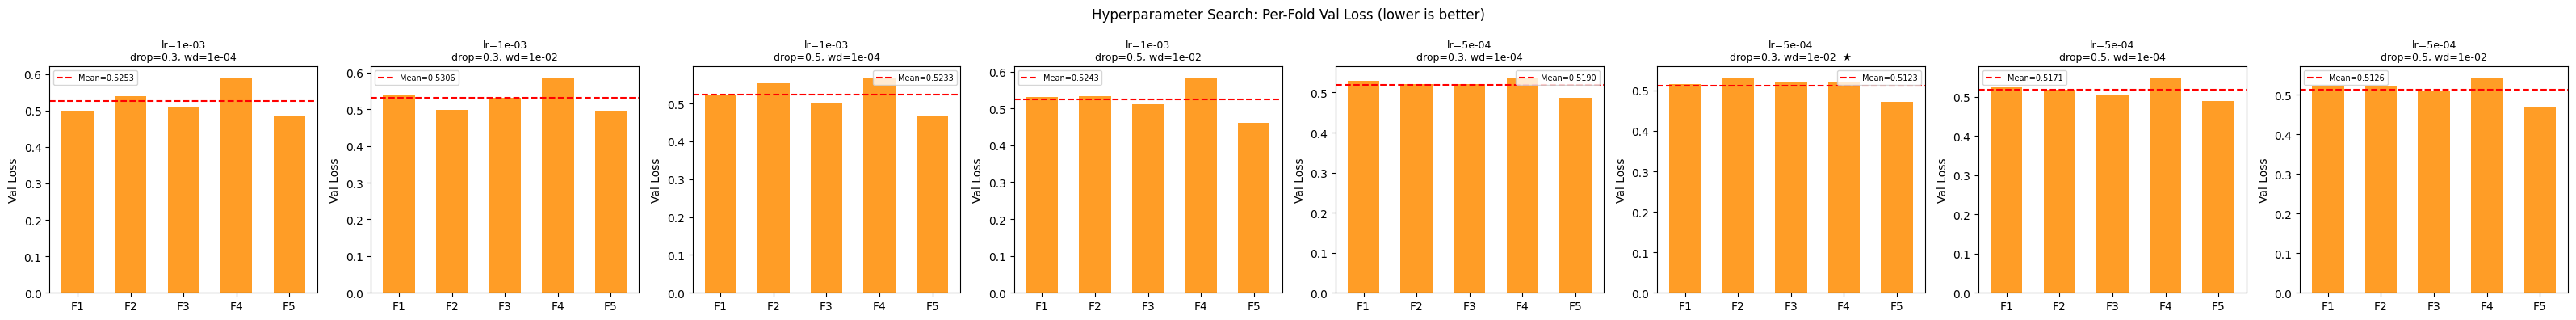

In [ ]:
# Per-fold val_loss bar chart — all 8 hyperparameter configs
fig, axes = plt.subplots(
    1, len(hp_results), figsize=(4 * len(hp_results), 4), sharey=False
)
if len(hp_results) == 1:
    axes = [axes]

_hp_keys = ["lr", "dropout", "weight_decay"]
for ax, r in zip(axes, hp_results):
    losses = [m["val_loss"] for m in r["fold_metrics"]]
    ax.bar(folds, losses, width=0.6, color="darkorange", alpha=0.85)
    ax.axhline(
        r["mean_val_loss"],
        color="red",
        linestyle="--",
        label=f"Mean={r['mean_val_loss']:.4f}",
    )
    ax.set_xticks(folds)
    ax.set_xticklabels([f"F{f}" for f in folds])
    ax.set_ylabel("Val Loss")
    is_best = all(r[k] == best_config[k] for k in _hp_keys)
    label = f"lr={r['lr']:.0e}\ndrop={r['dropout']}, wd={r['weight_decay']:.0e}"
    ax.set_title(label + ("  ★" if is_best else ""), fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Hyperparameter Search: Per-Fold Val Loss (lower is better)")
plt.tight_layout()
plt.show()

In [ ]:
# plot_history(best_history, title="Custom model 2")

### Full training


Only if best config is not the same as original config


In [ ]:
best_config == baseline_config

False

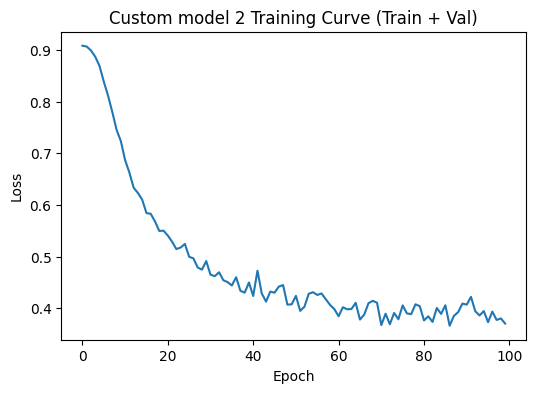

In [ ]:
if not best_config == baseline_config:
    custom2 = resnet.to(device)

    custom2.fc = nn.Sequential(
        nn.Linear(2048, 128),
        nn.ReLU(),
        nn.Dropout(best_config["dropout"]),
        nn.Linear(128, 1),
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(
        custom2.parameters(),
        lr=best_config["lr"],
        weight_decay=best_config["weight_decay"],
    )

    warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
    cosine = CosineAnnealingLR(optimizer, T_max=num_epochs - 5, eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

    # Full training
    custom2.train()
    train_losses = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in full_train_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = custom2(images).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(full_train_loader.dataset)
        train_losses.append(epoch_loss)
        scheduler.step()

    # Plot final training curve
    plt.figure(figsize=(6, 4))
    plt.plot(train_losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Custom model 2 Training Curve (Train + Val)")
    plt.show()

else:
    custom2 = custom1
    print(
        "Best hyperparameters are the same as in baseline and custom1. Models custom1 and custom2 are identical."
    )

### Evaluation


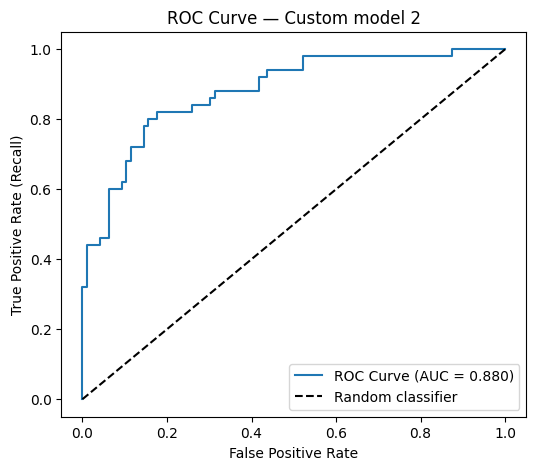

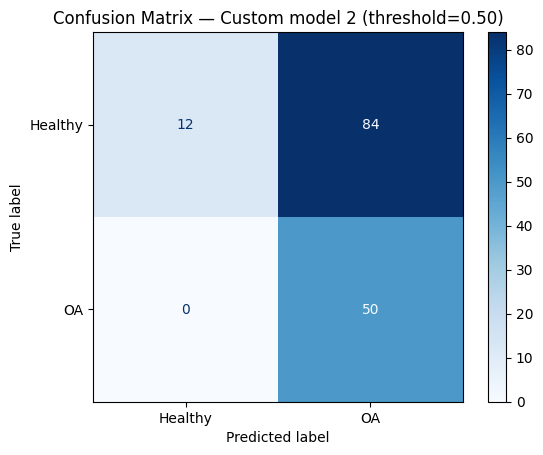


Test Metrics (Custom model 2) at threshold=0.03130887821316719:
  Accuracy : 0.4247
  F1 Score : 0.5435
  Recall   : 1.0000
  Precision: 0.3731


In [ ]:
results_custom2 = evaluate_model(
    custom2, test_loader, device, variant_name="Custom model 2", min_recall=1
)

In [ ]:
print(f"{'Metric':<20} {'Baseline':>12} {'Custom 1':>12} {'Custom 2':>12}")
print("-" * 59)
print(
    f"{'Recall':<20} {results_baseline['recall']:>12.4f} {results_custom1['recall']:>12.4f} {results_custom2['recall']:>12.4f}"
)
print(
    f"{'Precision':<20} {results_baseline['precision']:>12.4f} {results_custom1['precision']:>12.4f} {results_custom2['precision']:>12.4f}"
)
print(
    f"{'AUC':<20} {results_baseline['auc']:>12.4f} {results_custom1['auc']:>12.4f} {results_custom2['auc']:>12.4f}"
)
print(
    f"{'F1 Score':<20} {results_baseline['f1']:>12.4f} {results_custom1['f1']:>12.4f} {results_custom2['f1']:>12.4f}"
)
print(
    f"{'Accuracy':<20} {results_baseline['accuracy']:>12.4f} {results_custom1['accuracy']:>12.4f} {results_custom2['accuracy']:>12.4f}"
)
print(
    f"{'Threshold':<20} {results_baseline['threshold']:>12.3f} {results_custom1['threshold']:>12.3f} {results_custom2['threshold']:>12.4f}"
)

Metric                   Baseline     Custom 1     Custom 2
-----------------------------------------------------------
Recall                     0.9800       1.0000       1.0000
Precision                  0.9800       0.3846       0.3731
AUC                        0.9994       0.8829       0.8798
F1 Score                   0.9800       0.5556       0.5435
Accuracy                   0.9863       0.4521       0.4247
Threshold                   0.500        0.024       0.0313


### Threshold analysis (if necessary)


In [ ]:
# to_compare = [
#     [results_baseline, results_custom1],
#     ["baseline_model", "custom1"],
#     {"baseline_model": baseline_model, "custom1": custom1},
# ]

# idx_best_recall = np.argmax([to_compare[0][0]["recall"], to_compare[0][1]["recall"]])
# idx_best_precision = np.argmax(
#     [to_compare[0][0]["precision"], to_compare[0][1]["precision"]]
# )

# # if one model is better at both recall and precision, no threshold analysis required (ta_required)
# ta_required = False if (idx_best_recall == idx_best_precision) else True


# if ta_required:
#     # find threshold for worst model that equalizes recall with best model
#     results_worst_recall = to_compare[0][not idx_best_recall]

#     results_best_recall = to_compare[0][idx_best_recall]

#     best_recall = results_best_recall["recall"]

#     new_threshold, new_idx = select_threshold_by_recall(
#         fpr=results_worst_recall["fpr"],
#         tpr=results_worst_recall["tpr"],
#         thresholds=results_worst_recall["thresholds"],
#         min_recall=best_recall,
#     )

#     # recalculate metrics
#     new_preds = (results_worst_recall["all_probs"] > new_threshold).astype(int)
#     new_acc = accuracy_score(results_worst_recall["all_labels"], new_preds)
#     new_f1 = f1_score(results_worst_recall["all_labels"], new_preds)
#     new_rec = recall_score(results_worst_recall["all_labels"], new_preds)
#     new_prec = precision_score(
#         results_worst_recall["all_labels"], new_preds, zero_division=0
#     )

#     print(f"\nRecall-equalized Metrics at threshold={new_threshold}:")
#     print(f"  Accuracy : {new_acc:.4f}")
#     print(f"  F1 Score : {new_f1:.4f}")
#     print(f"  Recall   : {new_rec:.4f}")
#     print(f"  Precision: {new_prec:.4f}")

### Choose best model


In [ ]:
to_compare = [
    [results_baseline, results_custom1, results_custom2],
    ["baseline_model", "custom1", "custom2"],
    {"baseline_model": baseline_model, "custom1": custom1, "custom2": custom2},
]

best_model_idx = np.argmax(
    [
        to_compare[0][0]["precision"],
        to_compare[0][1]["precision"],
        to_compare[0][2]["precision"],
    ]
)
best_model_name = to_compare[1][best_model_idx]
best_model = to_compare[2][best_model_name]

print(f"The best model is {best_model_name}.")

The best model is baseline_model.


In [ ]:
# if ta_required:
#     # select best model based on recall-equalized precision
#     if new_prec <= results_best_recall["precision"]:
#         best_model = to_compare[2][to_compare[1][idx_best_recall]]
#     else:
#         best_model = to_compare[2][to_compare[1][not idx_best_recall]]

# else:
#     best_model = to_compare[2][to_compare[1][idx_best_recall]]

# print(f"The best model so far is ``.")

### Save and reload the model


In [ ]:
torch.save(best_model, "best_model.pth")
print("Best model saved!")

best_model = torch.load("best_model.pth", map_location=torch.device(device))
print("Best model loaded successfully!")

Best model saved!
Best model loaded successfully!


### Show images with predictions


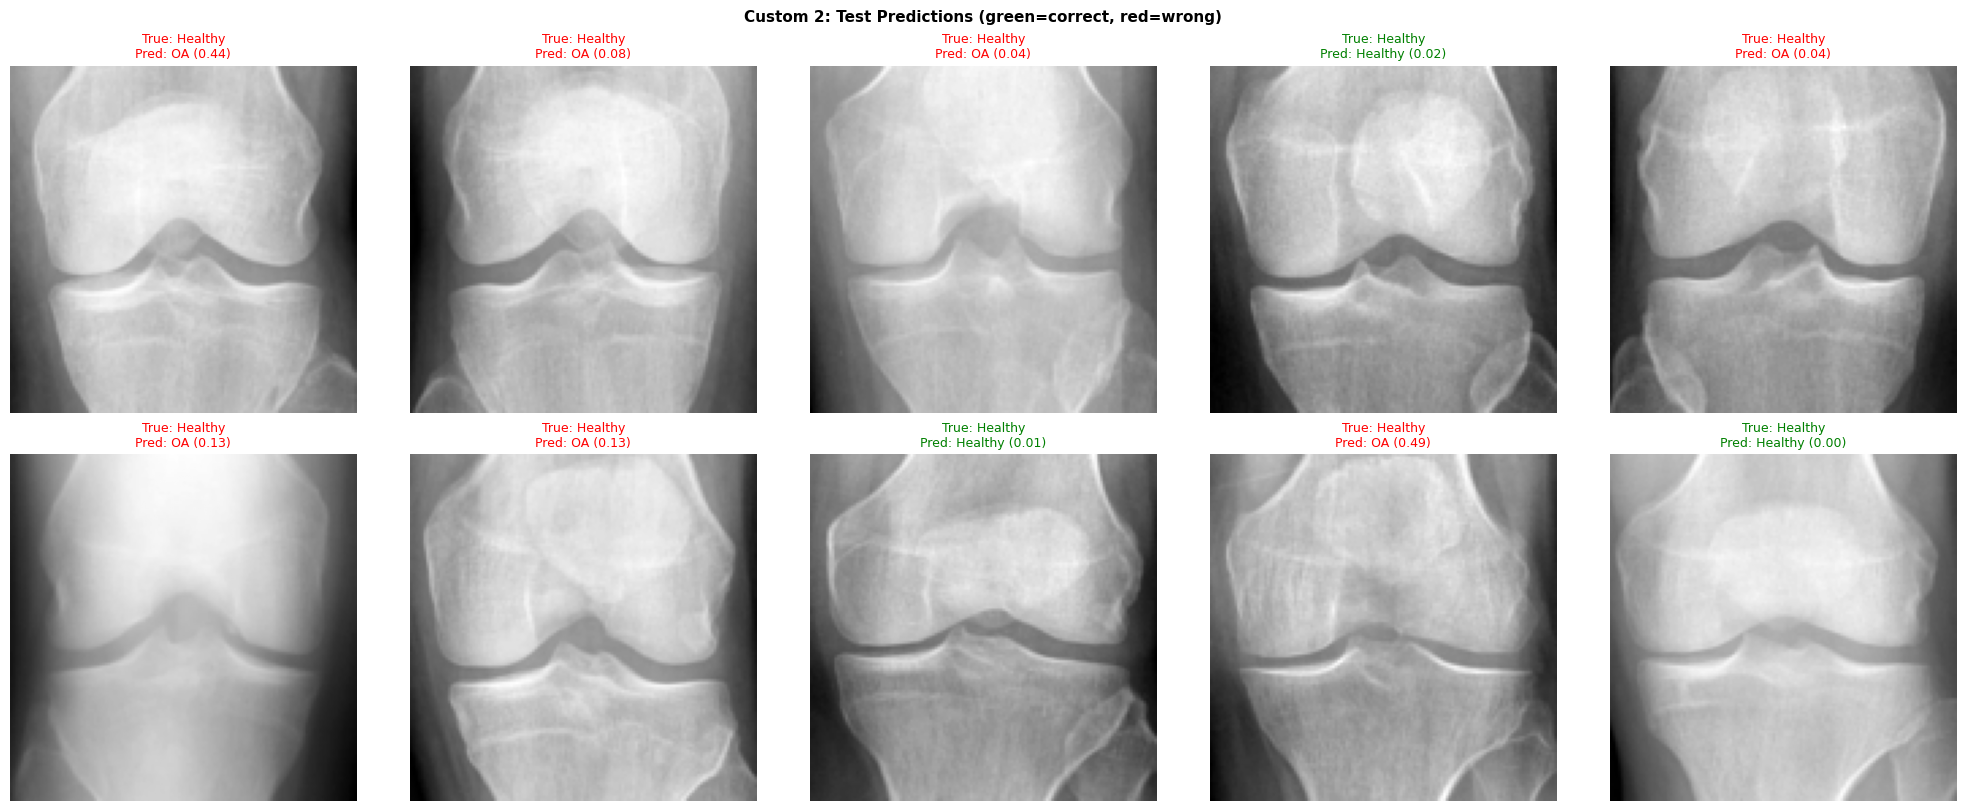

In [ ]:
display_dataset = datasets.ImageFolder(DATA_DIR + "test", transform=MyToTensor())
CLASS_NAMES = ["Healthy", "OA"]

show_images(
    list(range(10)),
    display_dataset,
    results_custom2["all_labels"],
    results_custom2["final_preds"],
    results_custom2["all_probs"],
    CLASS_NAMES,
    title="Custom 2: Test Predictions (green=correct, red=wrong)",
)

---


## 4.3 Custom model 3


The architecture is identical to `custom1` and `custom2` but some of the pretrained weights are opened for further training.


### Data preparation


See earlier: claude convo 22/4


### Model preparation


In [ ]:
custom3 = resnet.to(device)

Freeze all parameters


In [ ]:
for param in custom3.parameters():
    param.requires_grad = False

Replace linear classifier


In [ ]:
custom3.fc = nn.Sequential(
    nn.Flatten(),
    nn.Linear(2048, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 1),
).to(device)

Unfreeze all or some of the parameters of `ResNet50`


In [ ]:
for param in custom3.layer4[-1].parameters():
    param.requires_grad = True

In [ ]:
# Alternatively, unfreeze all of layer 4.
# 15e06 trainable parameters ...
# Suggestion: optional, only if previous does not improve model performance?
# for param in custom3.layer4.parameters():
#     param.requires_grad = True

In [ ]:
# Check how many parameters are frozen and not frozen
frozen = sum(p.numel() for p in custom3.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in custom3.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Trainable: 4,724,993 | Frozen: 19,045,440


### Hyperparameter search


We don't perform an additional hyperparameter search.


### Full training


In [ ]:
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader = DataLoader(
    full_train_dataset, batch_size=BATCH_SIZE, shuffle=True, **_loader_kw
)

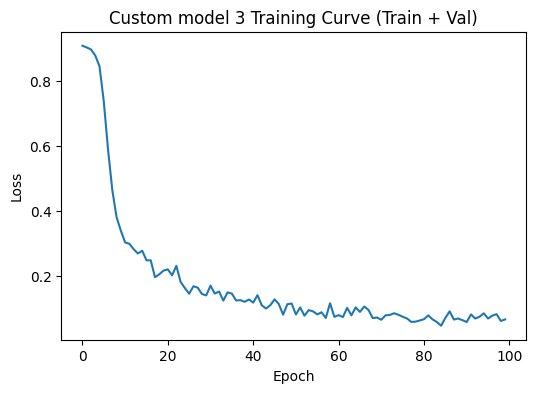

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(
    custom3.parameters(), lr=best_config["lr"], weight_decay=best_config["weight_decay"]
)

warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=num_epochs - 5, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])


custom3.train()
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in full_train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = custom3(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader.dataset)
    train_losses.append(epoch_loss)
    scheduler.step()

# Plot final training curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom model 3 Training Curve (Train + Val)")
plt.show()

### Evaluation


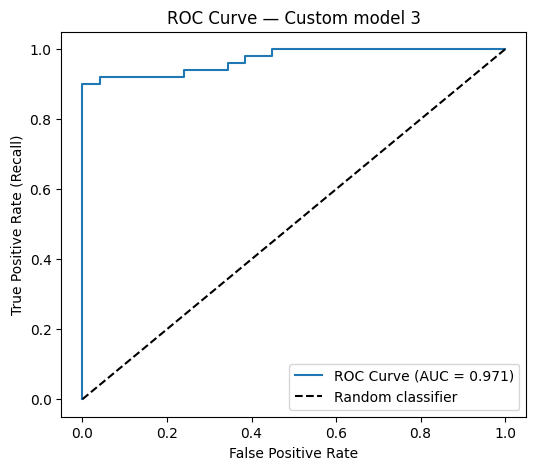

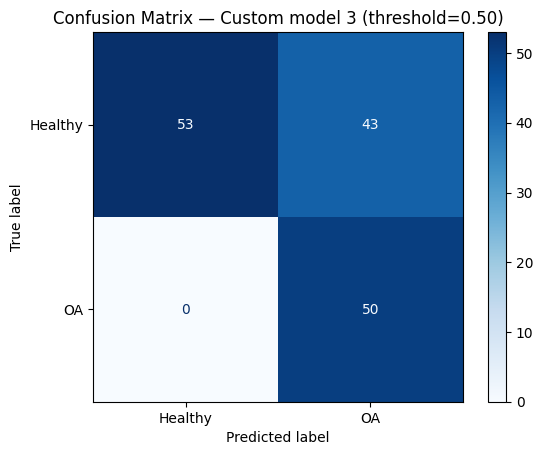


Test Metrics (Custom model 3) at threshold=0.0066896467469632626:
  Accuracy : 0.7055
  F1 Score : 0.6993
  Recall   : 1.0000
  Precision: 0.5376


In [ ]:
results_custom3 = evaluate_model(
    custom3, test_loader, device, variant_name="Custom model 3", min_recall=1
)

In [ ]:
print(
    f"{'Metric':<20} {'Baseline':>12} {'Custom 1':>12} {'Custom 2':>12} {'Custom 3':>12}"
)
print("-" * 72)
print(
    f"{'Recall':<20} {results_baseline['recall']:>12.4f} {results_custom1['recall']:>12.4f} {results_custom2['recall']:>12.4f} {results_custom3['recall']:>12.4f}"
)
print(
    f"{'Precision':<20} {results_baseline['precision']:>12.4f} {results_custom1['precision']:>12.4f} {results_custom2['precision']:>12.4f} {results_custom3['precision']:>12.4f}"
)
print(
    f"{'AUC':<20} {results_baseline['auc']:>12.4f} {results_custom1['auc']:>12.4f} {results_custom2['auc']:>12.4f} {results_custom3['auc']:>12.4f}"
)
print(
    f"{'F1 Score':<20} {results_baseline['f1']:>12.4f} {results_custom1['f1']:>12.4f} {results_custom2['f1']:>12.4f} {results_custom3['f1']:>12.4f}"
)
print(
    f"{'Accuracy':<20} {results_baseline['accuracy']:>12.4f} {results_custom1['accuracy']:>12.4f} {results_custom2['accuracy']:>12.4f} {results_custom3['accuracy']:>12.4f}"
)
print(
    f"{'Threshold':<20} {results_baseline['threshold']:>12.3f} {results_custom1['threshold']:>12.3f} {results_custom2['threshold']:>12.4f} {results_custom3['threshold']:>12.4f}"
)

Metric                   Baseline     Custom 1     Custom 2     Custom 3
------------------------------------------------------------------------
Recall                     0.9800       1.0000       1.0000       1.0000
Precision                  0.9800       0.3846       0.3731       0.5376
AUC                        0.9994       0.8829       0.8798       0.9708
F1 Score                   0.9800       0.5556       0.5435       0.6993
Accuracy                   0.9863       0.4521       0.4247       0.7055
Threshold                   0.500        0.024       0.0313       0.0067


Note: if model performance `custom3` disappoints, try lower learning rate for unfrozen conv layers only! = protect prelearned features better against "aggressive" retraining


### Choose best model


In [ ]:
to_compare = [
    [results_baseline, results_custom1, results_custom2, results_custom3],
    ["baseline_model", "custom1", "custom2", "custom3"],
    {
        "baseline_model": baseline_model,
        "custom1": custom1,
        "custom2": custom2,
        "custom3": custom3,
    },
]

best_model_idx = np.argmax(
    [
        to_compare[0][0]["precision"],
        to_compare[0][1]["precision"],
        to_compare[0][2]["precision"],
        to_compare[0][3]["precision"],
    ]
)
best_model_name = to_compare[1][best_model_idx]
best_model = to_compare[2][best_model_name]

print(f"The best model is {best_model_name}.")

The best model is baseline_model.


### Show images with predictions


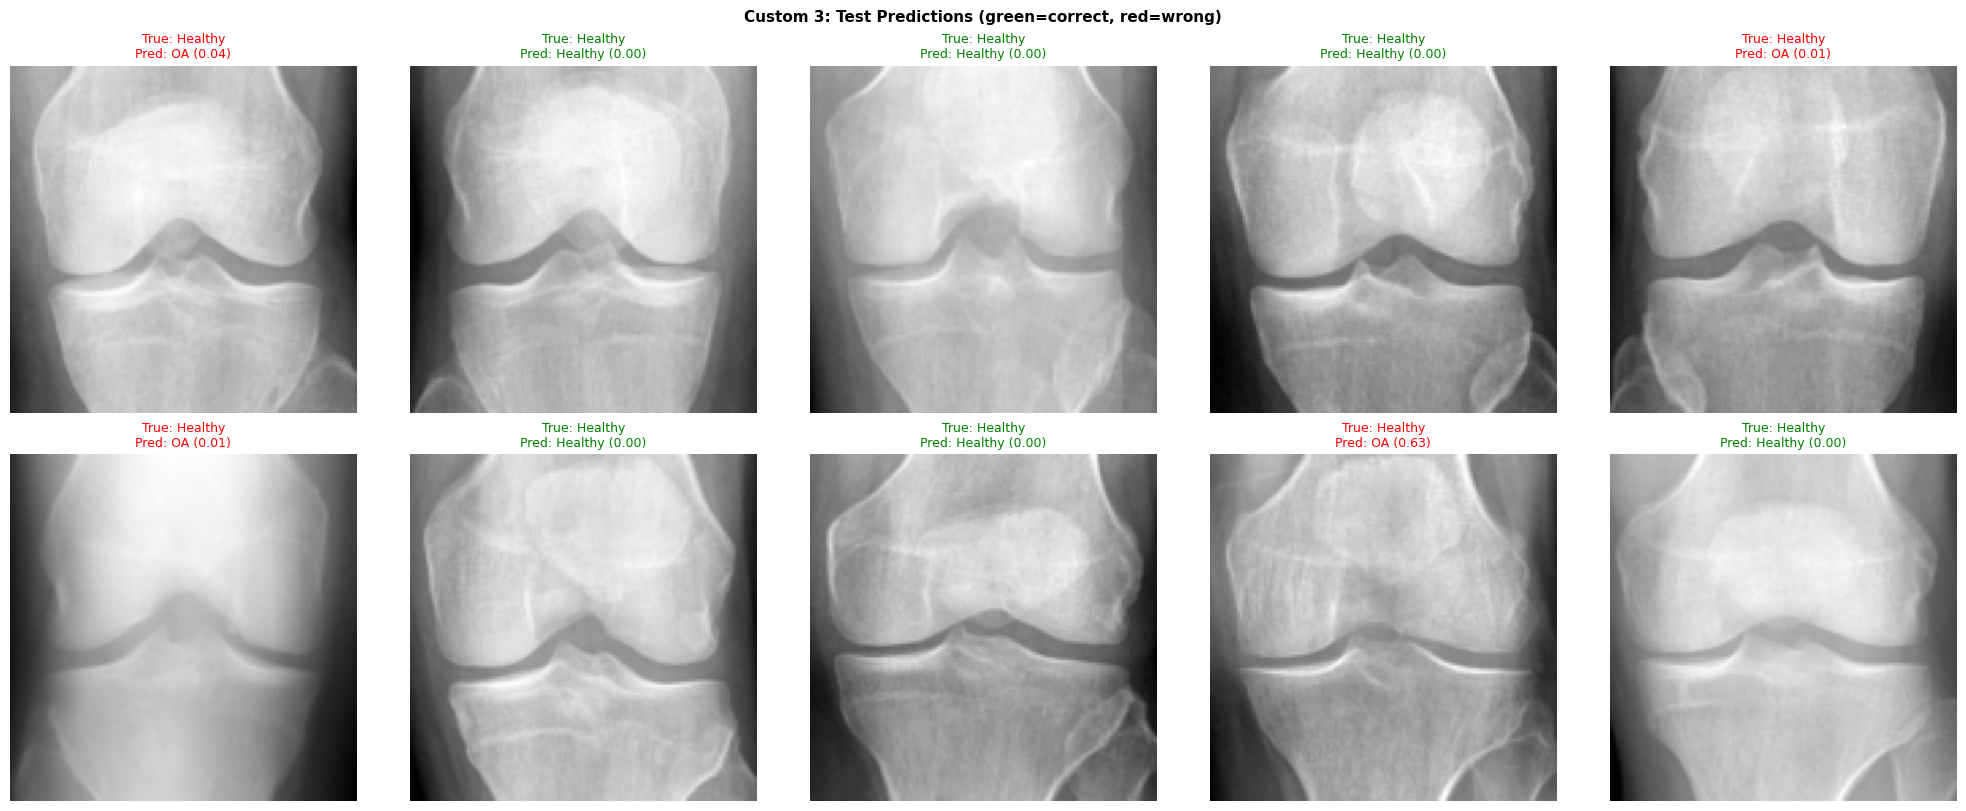

In [ ]:
display_dataset = datasets.ImageFolder(DATA_DIR + "test", transform=MyToTensor())
CLASS_NAMES = ["Healthy", "OA"]

show_images(
    list(range(10)),
    display_dataset,
    results_custom3["all_labels"],
    results_custom3["final_preds"],
    results_custom3["all_probs"],
    CLASS_NAMES,
    title="Custom 3: Test Predictions (green=correct, red=wrong)",
)

## 4.4 Save best model


In [ ]:
torch.save(best_model, "best_model_final.pth")
print("Best model saved!")

Best model saved!


---


# 5. Discussion


Compare specific models and discuss the implications.


## 5.1 Custom model 1 versus baseline


Using features learned in a different classification task. We added a very simple block to the `ResNet50`


In [ ]:
# print(f"{'Metric':<20} {'Variant A':>12} {'Variant B':>12}")
# print("-" * 46)
# print(f"{'AUC':<20} {results_custom1['auc']:>12.4f} {results_baseline['auc']:>12.4f}")
# print(f"{'Recall':<20} {results_custom1['recall']:>12.4f} {results_baseline['recall']:>12.4f}")
# print(f"{'F1 Score':<20} {results_custom1['f1']:>12.4f} {results_baseline['f1']:>12.4f}")
# print(f"{'Accuracy':<20} {results_custom1['accuracy']:>12.4f} {results_baseline['accuracy']:>12.4f}")
# print(f"{'Precision':<20} {results_custom1['precision']:>12.4f} {results_baseline['precision']:>12.4f}")
# print(f"{'Threshold':<20} {results_custom1['threshold']:>12.3f} {results_baseline['threshold']:>12.3f}")

## 5.2 Custom model 2 versus custom model 1


Does finetuning affect model performance?


In [ ]:
# print(f"{'Metric':<20} {'Variant A':>12} {'Variant B':>12}")
# print("-" * 46)
# print(f"{'AUC':<20} {results_custom1['auc']:>12.4f} {results_custom2['auc']:>12.4f}")
# print(
#     f"{'Recall':<20} {results_custom1['recall']:>12.4f} {results_custom2['recall']:>12.4f}"
# )
# print(f"{'F1 Score':<20} {results_custom1['f1']:>12.4f} {results_custom2['f1']:>12.4f}")
# print(
#     f"{'Accuracy':<20} {results_custom1['accuracy']:>12.4f} {results_custom2['accuracy']:>12.4f}"
# )
# print(
#     f"{'Precision':<20} {results_custom1['precision']:>12.4f} {results_custom2['precision']:>12.4f}"
# )
# print(
#     f"{'Threshold':<20} {results_custom1['threshold']:>12.3f} {results_custom2['threshold']:>12.3f}"
# )

## 5.3 Custom model 3 versus custom model 2


What is the effect of retraining the prelearned features on model performance?


In [ ]:
# print(f"{'Metric':<20} {'Variant A':>12} {'Variant B':>12}")
# print("-" * 46)
# print(f"{'AUC':<20} {results_custom2['auc']:>12.4f} {results_custom3['auc']:>12.4f}")
# print(
#     f"{'Recall':<20} {results_custom2['recall']:>12.4f} {results_custom3['recall']:>12.4f}"
# )
# print(f"{'F1 Score':<20} {results_custom2['f1']:>12.4f} {results_custom3['f1']:>12.4f}")
# print(
#     f"{'Accuracy':<20} {results_custom2['accuracy']:>12.4f} {results_custom3['accuracy']:>12.4f}"
# )
# print(
#     f"{'Precision':<20} {results_custom2['precision']:>12.4f} {results_custom3['precision']:>12.4f}"
# )
# print(
#     f"{'Threshold':<20} {results_custom2['threshold']:>12.3f} {results_custom3['threshold']:>12.3f}"
# )

---


In [ ]:
# plt.figure(figsize=(7, 6))
# plt.plot(
#     results_A_test["fpr"], results_A_test["tpr"],
#     label=f"Variant A — all data (AUC = {results_A_test['auc']:.3f})",
# )
# plt.plot(
#     results_baseline["fpr"], results_baseline["tpr"],
#     label=f"Variant B — no outliers (AUC = {results_baseline['auc']:.3f})",
# )
# plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate (Recall)")
# plt.title("ROC Curve Comparison — Baseline CNN")
# plt.legend()
# plt.show()

---

# 6. Save best model


In [ ]:
# Save the best variant for use in downstream notebooks (latent space, GradCAM)
# if results_baseline["recall"] >= results_A_test["recall"] and results_baseline["auc"] >= results_A_test["auc"]:
#     best_variant = "B"
#     torch.save(loaded_model_B.state_dict(), "baseline_best.pth")
# else:
#     best_variant = "A"
#     torch.save(loaded_model_A.state_dict(), "baseline_best.pth")

# print(f"Best baseline: Variant {best_variant} saved as baseline_best.pth")

---
